In [1]:
import os, sys
from pathlib import Path
os.chdir(Path(r"C:\Users\amand\OneDrive - Fisk University\Documents\ResumeBiasResearch"))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
baseline = pd.read_csv('results/tables/baseline_model_performance.csv')
by_label = pd.read_csv('results/tables/model_by_label_type.csv')
intervention = pd.read_csv('results/tables/fairness_intervention_comparison.csv')

print("=== Baseline (blind labels) ===")
print(baseline[['model', 'test_accuracy', 'test_f1', 'test_auc']].to_string(index=False))

print("\n=== By label type ===")
print(by_label.pivot(index='model', columns='label_type', values='auc').to_string())

print("\n=== Intervention ===")
print(intervention[['model', 'stage', 'accuracy', 'dpd', 'eod']].to_string(index=False))

=== Baseline (blind labels) ===
              model  test_accuracy  test_f1  test_auc
logistic_regression       0.967292 0.965832  0.996488
      random_forest       0.851458 0.849292  0.944065
            xgboost       0.944375 0.941614  0.990706

=== By label type ===
label_type              blind  ethnicity    gender
model                                             
logistic_regression  0.996488   0.996503  0.994340
random_forest        0.944065   0.945041  0.942514
xgboost              0.990706   0.990918  0.988038

=== Intervention ===
              model      stage  accuracy      dpd      eod
logistic_regression   baseline  0.956667 0.508350 0.963463
      random_forest   baseline  0.863333 0.516447 0.877878
            xgboost   baseline  0.937917 0.505820 0.942943
logistic_regression reweighted  0.956250 0.509362 0.964464
      random_forest reweighted  0.863750 0.516953 0.879379
            xgboost reweighted  0.935833 0.509615 0.944444


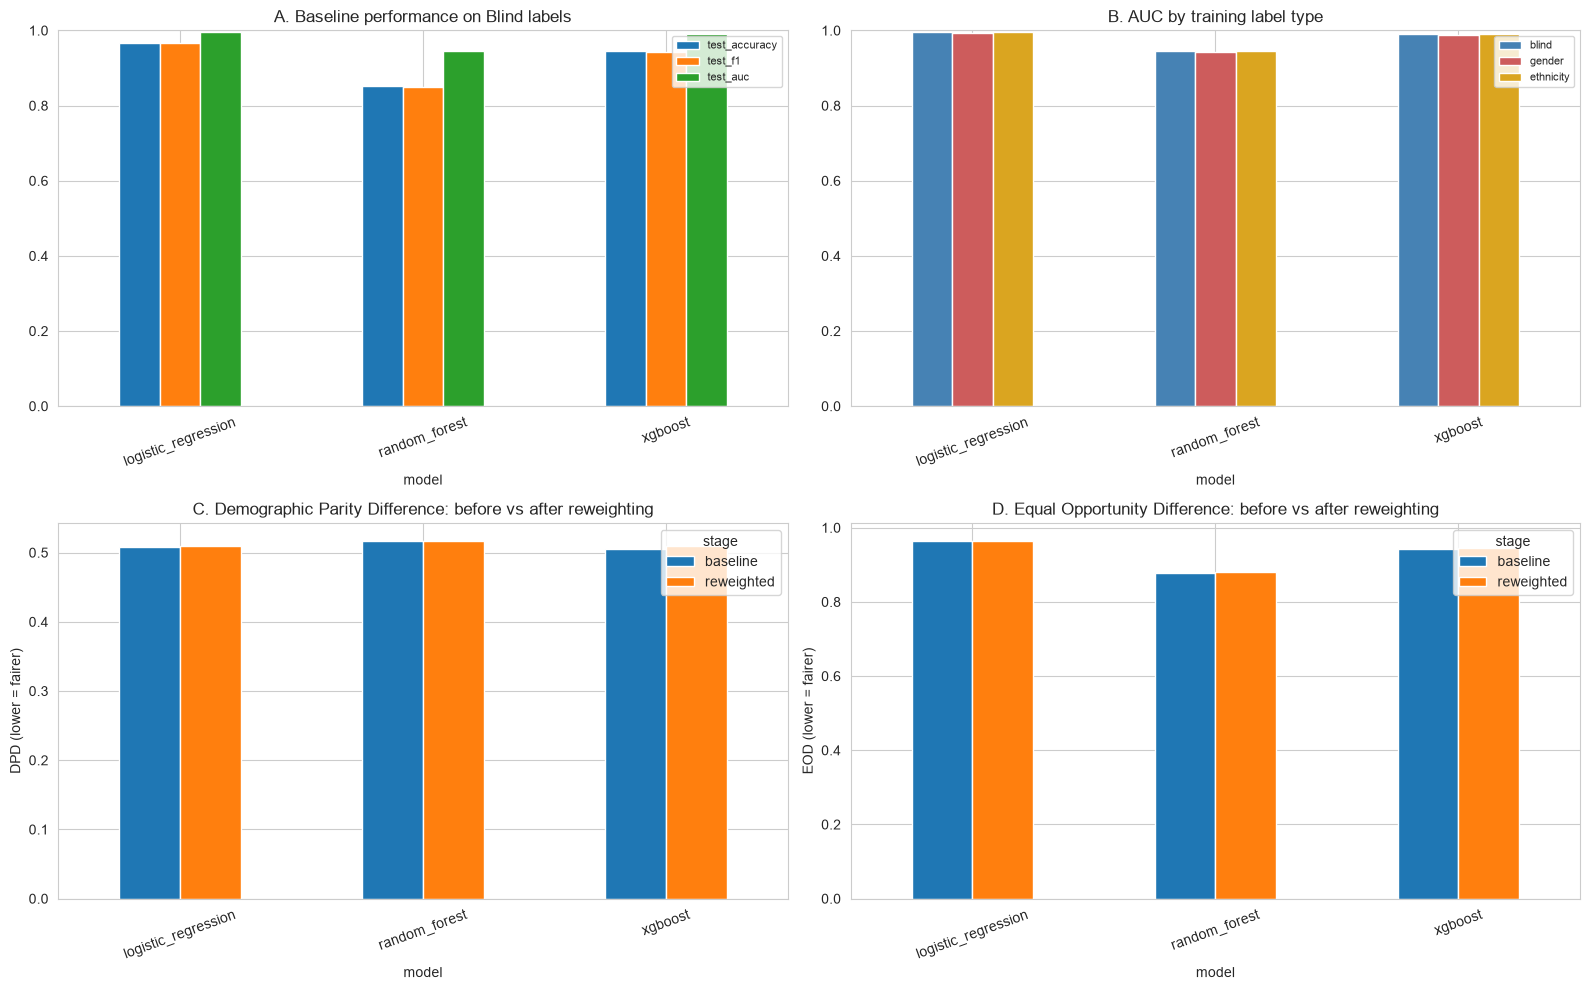

In [3]:
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 2, 1)
baseline.set_index('model')[['test_accuracy', 'test_f1', 'test_auc']].plot(kind='bar', ax=ax1)
ax1.set_title('A. Baseline performance on Blind labels')
ax1.set_ylim(0, 1)
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=20)

ax2 = plt.subplot(2, 2, 2)
by_label.pivot(index='model', columns='label_type', values='auc')[['blind','gender','ethnicity']].plot(
    kind='bar', ax=ax2, color=['steelblue', 'indianred', 'goldenrod'])
ax2.set_title('B. AUC by training label type')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=20)

ax3 = plt.subplot(2, 2, 3)
intervention.pivot(index='model', columns='stage', values='dpd').plot(kind='bar', ax=ax3)
ax3.set_title('C. Demographic Parity Difference: before vs after reweighting')
ax3.set_ylabel('DPD (lower = fairer)')
ax3.tick_params(axis='x', rotation=20)

ax4 = plt.subplot(2, 2, 4)
intervention.pivot(index='model', columns='stage', values='eod').plot(kind='bar', ax=ax4)
ax4.set_title('D. Equal Opportunity Difference: before vs after reweighting')
ax4.set_ylabel('EOD (lower = fairer)')
ax4.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('results/figures/08_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of Findings

**1. Models are accurate on blind labels.** [fill from output]

**2. Model choice matters less than label quality.** [fill from output]

**3. Counterfactual name sensitivity.** [fill from output]

**4. Reweighting effect on fairness.** [fill from output]